Simple notebook displaying the key transformations used on the data set depending on the visual referential explored : 

* Retinotopic : Use of the log polar grid 
* Cartesian : Circular crop to match the retinotopic visual field 

In [1]:
from retinotopy import *
welcome()

--------------------------------------------------------------------------------------------------------
On date 2025-11-13, Running learning on host eduroam-1-40-87.univ-amu.fr with device mps, pytorch==2.9.1
--------------------------------------------------------------------------------------------------------
Welcome on macOS-26.1-arm64-arm-64bit-Mach-O


In [2]:
data_set_types

['full', 'bbox']

data_set_type='full'
--------------------------------------------------
args.do_polar=True
Loaded 50000 images under val
Loaded 1281167 images under train


/Users/laurent/sdrive_cnrs/hot_from_git/Retinotopy_project/Retinotopy/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


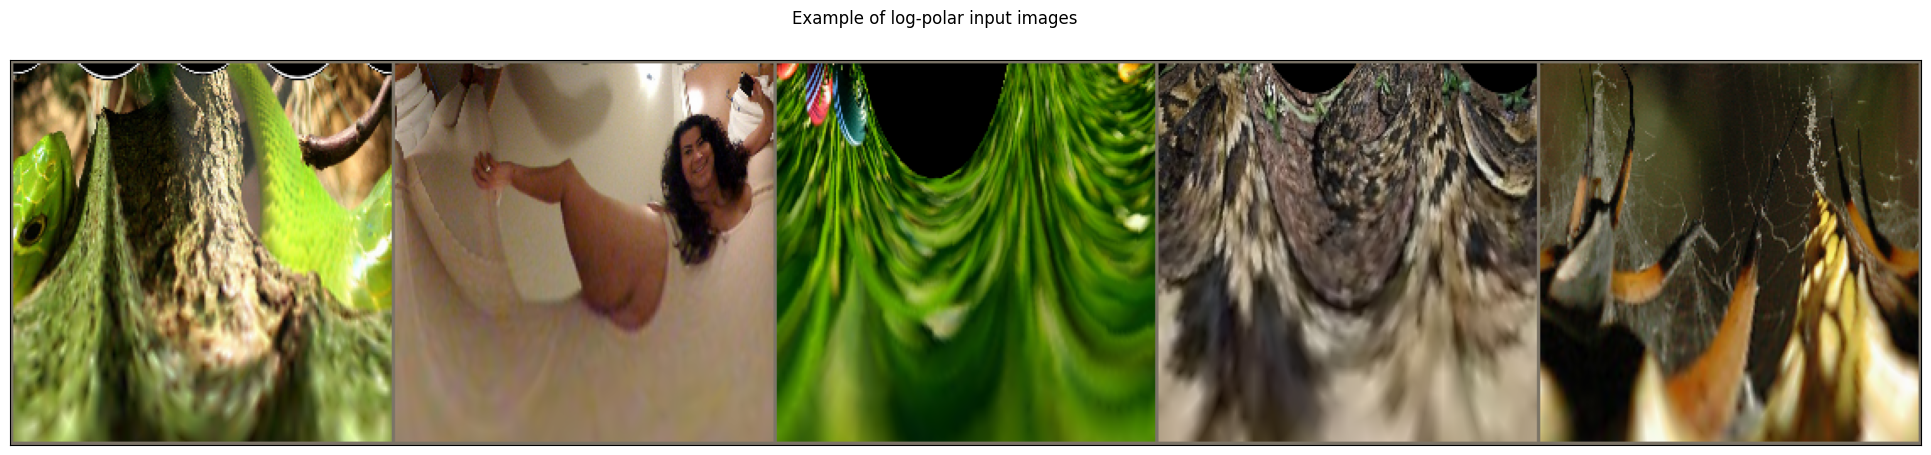

args.do_polar=False
Loaded 50000 images under val
Loaded 1281167 images under train


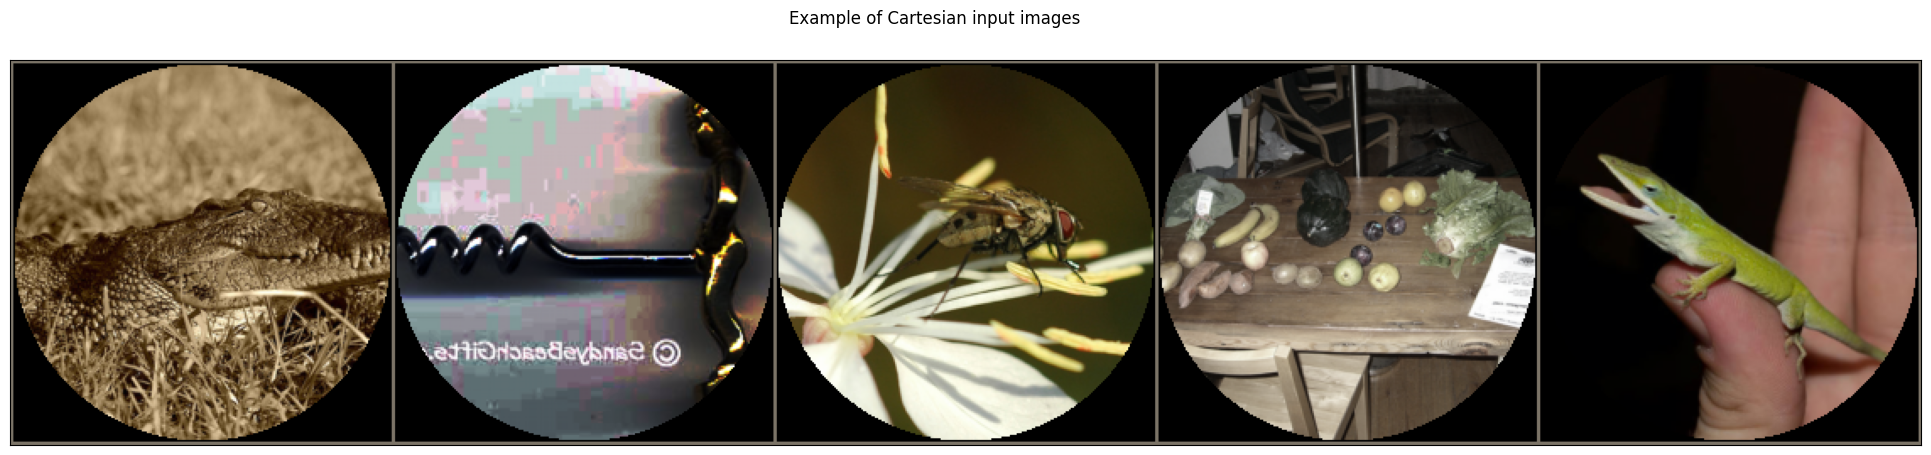

data_set_type='bbox'
--------------------------------------------------
args.do_polar=True


FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/SSD1TO/DeepLearningDatasets/Imagenet_bbox/val'

In [3]:
for data_set_type in data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')
    args = Params()
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images to perform the training
    print(50*'-')

    for args.do_polar in [True, False]:
        print(f'{args.do_polar=}')
        dataloaders = datasets_transforms(args)
        for i_step, (images, labels) in enumerate(dataloaders['train']):
            images, labels = images.to('cpu'), labels.to('cpu')
            break
        imshow(images[:5], title='Example of Cartesian input images' if not(args.do_polar) else 'Example of log-polar input images', fig_height=5)
        plt.show()
    print(50*'=')